# Clase 2 — Data Profiling & Visualización
**Analítica de Datos · Negocios Digitales · UdeSA · Otoño 2026**

---

El TP pide elegir un dataset del [portal de datos abiertos de Buenos Aires](https://data.buenosaires.gob.ar/), encontrar un insight interesante y contarlo en un video de 3-5 minutos.

**Lo que hacemos hoy es exactamente eso** — con Superstore (ventas retail de EEUU) como dataset de ejemplo. Al terminar vas a poder replicar el mismo flujo con tu dataset de GCBA.

| Paso | Acción | Objetivo |
|---|---|---|
| **1. Pregunta** | Definís qué querés descubrir | Una pregunta concreta y relevante |
| **2. Exploración** | Entendés el dataset | Variables, calidad de datos, distribuciones |
| **3. Insight** | Encontrás algo no obvio | Un patrón, tendencia o anomalía |
| **4. Visualización** | Mostrás el hallazgo | Un gráfico que se entienda en 5 segundos |
| **5. Historia** | Lo contás claramente | Intro → datos → insight → conclusión |

Este notebook sigue esos 5 pasos. Al final hay una sección **Extra** con más herramientas para explorar en casa.

---
## 0. Setup

In [289]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)


In [290]:
df = pd.read_csv('Superstore.csv', encoding='latin')
pd.set_option('display.max_columns', None)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,NaN,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,NaN,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


---
## Paso 1 — La Pregunta

El análisis empieza con una pregunta, no con código.

Una buena pregunta para el TP tiene tres características:
- **Concreta:** "¿qué línea de colectivo tiene más demoras en hora pico?" — no "¿cómo es el transporte?"
- **Accionable:** la respuesta le cambia algo a alguien — a un ciudadano, a un funcionario, a una empresa
- **Interesante:** alguien fuera de la materia querría conocer la respuesta

| Pregunta débil | Pregunta fuerte |
|---|---|
| ¿Cómo son los datos de tránsito? | ¿En qué barrios se concentran los accidentes viales nocturnos? |
| ¿Hay muchas obras públicas? | ¿Qué comunas tienen más obras con plazos vencidos? |
| ¿Cómo evolucionó Ecobici? | ¿El uso de Ecobici cayó durante la pandemia y luego se recuperó? |
| ¿Qué pasa con la basura? | ¿Hay barrios con mayor concentración de reclamos de higiene? |

---

**Nuestra pregunta de hoy:**
> *¿Qué categoría de producto genera más valor para el negocio — en ventas y en margen de ganancia?*

---
## Paso 2 — Exploración del dataset

Antes de buscar insights, necesitamos entender qué tenemos.

Tres preguntas básicas:
1. ¿Qué variables hay y de qué tipo son?
2. ¿Hay datos faltantes? ¿Por qué?
3. ¿Cómo se distribuyen los valores clave?

In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9195 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [292]:
# Parsear 'Order Date' y 'Ship Date' a datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=False)

In [309]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,NaN,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,NaN,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


> **¿Qué miramos?**
> - **Tipos de dato:** ¿están bien asignados? Fechas como `datetime64`, números como `float64` o `int64`
> - **Non-Null Count:** si es menor que el total (9994), hay nulos — anotá en qué columnas

### Clasificación de variables

Antes de graficar o calcular, necesitamos saber **qué tipo de variable es cada columna** — porque el tipo determina qué análisis tiene sentido hacer. Una variable nominal no tiene "promedio", tiene "valor más frecuente".

| Columna | Tipo | Por qué importa |
|---|---|---|
| `Sales`, `Profit` | Numérica continua | Calculamos media, mediana, vemos distribución |
| `Quantity` | Numérica discreta | Solo valores enteros (1, 2, 3...) |
| `Discount` | Numérica continua | Va de 0 a 1, representa un porcentaje |
| `Category`, `Region` | Categórica nominal | No tienen orden natural |
| `Segment` | Categórica ordinal | Consumer / Corporate / Home Office |
| `Order Date` | Fecha | Permite analizar tendencias en el tiempo |
| `Order ID` | Variable compuesta | Codifica año + región + secuencia (CA-2016-152156) — contiene info pero no se analiza directamente |
| `Customer Name` | ID / texto | No se analiza estadísticamente |

###
> **Para el TP:** clasificá cada columna de tu dataset antes de hacer cualquier análisis. De esta clasificación se desprende todo: qué graficás, cómo calculás, qué podés comparar.

In [293]:
# ¿Cuántas categorías tiene cada variable categórica?
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} valores únicos → {df[col].unique()}')

Ship Mode: 4 valores únicos → ['Second Class' 'Standard Class' 'First Class' 'Same Day']
Segment: 3 valores únicos → ['Consumer' 'Corporate' 'Home Office']
Region: 4 valores únicos → ['South' 'West' 'Central' 'East']
Category: 3 valores únicos → ['Furniture' 'Office Supplies' 'Technology']
Sub-Category: 17 valores únicos → ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [294]:
df.drop(['Order Date', 'Ship Date'], axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.00,4997.50,2885.16,1.00,2499.25,4997.50,7495.75,9994.00
Postal Code,9195.00,55236.59,32103.32,1040.00,22980.00,57103.00,90008.00,99301.00
Sales,9994.00,229.86,623.25,0.44,17.28,54.49,209.94,22638.48
Quantity,9994.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9195.00,0.15,0.20,0.00,0.00,0.20,0.20,0.80
Profit,9195.00,29.72,228.45,-3839.99,1.75,8.67,29.29,8399.98


> **¿Qué miramos?**
> - La **diferencia entre media y mediana (50%):** si están muy separadas, hay outliers que distorsionan el promedio
> - El **mínimo y máximo:** ¿hay valores imposibles? (fechas en el futuro, precios negativos, edades = 999)
> - El **Profit mínimo es negativo** → hay órdenes que generan pérdidas reales
>

### Datos faltantes — ¿qué información nos falta y por qué?

En cualquier dataset real van a encontrar datos faltantes. Lo importante no es solo detectarlos, sino entender **si tienen un patrón** — porque eso cambia completamente la estrategia de limpieza.

In [295]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100).round(1)
resumen = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)


,Nulos,% del total
Postal Code,799,8.00
Discount,799,8.00
Profit,799,8.00


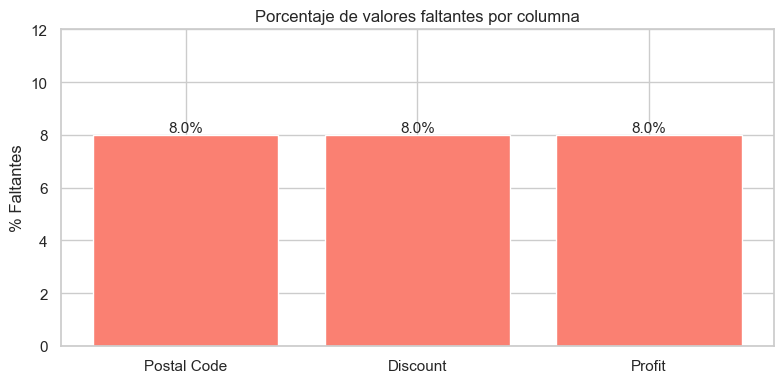

In [ ]:
plt.figure(figsize=(8, 4))
cols_con_nulos = nulos_pct[nulos_pct > 0].sort_values(ascending=False)
bars = plt.bar(cols_con_nulos.index, cols_con_nulos.values, color='salmon', edgecolor='white')
for bar, val in zip(bars, cols_con_nulos.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val}%', ha='center', fontsize=11)
plt.title('Porcentaje de valores faltantes por columna')
plt.ylabel('% Faltantes')
plt.ylim(0, 12)
plt.tight_layout()
plt.show()

### ¿Por qué faltan estos datos? — MCAR, MAR y MNAR

No todos los datos faltantes son iguales. La clase teórica define tres patrones:

| Tipo | Definición | Ejemplo del PDF |
|---|---|---|
| **MCAR** | Missing **Completely** at Random — la ausencia es aleatoria, no depende de ninguna variable | Participantes que olvidaron responder preguntas al azar |
| **MAR** | Missing **at** Random — depende de variables *observables*, no del valor que falta | Entrevistados mayores de 40 no reportan salario |
| **MNAR** | Missing **Not** at Random — depende del *valor que falta* | Personas con salarios más altos evitan contestar |

**¿Por qué importa el tipo?**
Porque cambia la estrategia y el sesgo que introducimos al imputar.
MCAR es el más fácil — podés imputar con poca distorsión.
MNAR es el más problemático — si imputás, podés estar ocultando el patrón real.

---

**¿Qué tipo tienen los nulos de Superstore?**

Las mismas 799 filas son nulas en Postal Code, Discount *y* Profit simultáneamente.
Eso sugiere filas mal cargadas — la ausencia no parece relacionada con ningún valor de negocio.
Clasificación probable: **MCAR**.

> **Caso MNAR en Superstore:** si solo faltaran los Profits de órdenes con pérdidas
> (las filiales no reportan sus fracasos), imputar con la mediana ocultaría el problema.
> Antes de imputar, siempre preguntarse: *¿por qué falta este dato?*


### ¿Qué hacemos con los nulos?

| Columna | Estrategia | Por qué |
|---|---|---|
| `Postal Code` | Dejar nulos | No afecta el análisis de ventas y margen |
| `Discount` | Imputar con `0` | Si no hay registro, probablemente el descuento fue 0 |
| `Profit` | Imputar con mediana | No podemos asumir 0 — puede ser positivo o negativo |
###
> **Para el TP:** para cada columna con nulos, preguntate *¿por qué falta este dato?* Si los nulos en una columna de ingresos corresponden siempre a los salarios más altos → es MNAR → imputar con la media va a sesgar tu análisis hacia abajo.

In [297]:
df['Discount'] = df['Discount'].fillna(0)
df['Profit']   = df['Profit'].fillna(df['Profit'].median())

print('Nulos restantes:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Nulos restantes:
Postal Code    799
dtype: int64


---
## Paso 3 — Descubrimiento del insight

Con el dataset limpio, ahora buscamos patrones.

Dos herramientas clave:
- **Estadística descriptiva:** media, mediana — para entender cómo se distribuye una variable
- **Agrupaciones (`groupby`):** comparar categorías — la herramienta más poderosa para encontrar insights

**Nuestra pregunta:** *¿qué categoría de producto genera más valor?*

### Distribución de ventas — antes de agrupar

Primero entendemos cómo se distribuye la variable que queremos analizar. ¿Hay una venta "típica" o hay mucha variabilidad?

In [298]:
ventas = df['Sales'].dropna()

media   = ventas.mean()
mediana = ventas.median()
moda    = ventas.mode()[0]

print(f'Media de ventas:   ${media:,.2f}')
print(f'Mediana de ventas: ${mediana:,.2f}')
print(f'Moda de ventas:    ${moda:,.2f}')
print(f'Diferencia media-mediana: ${media - mediana:,.2f}')


Media de ventas:   $229.86
Mediana de ventas: $54.49
Moda de ventas:    $12.96
Diferencia media-mediana: $175.37


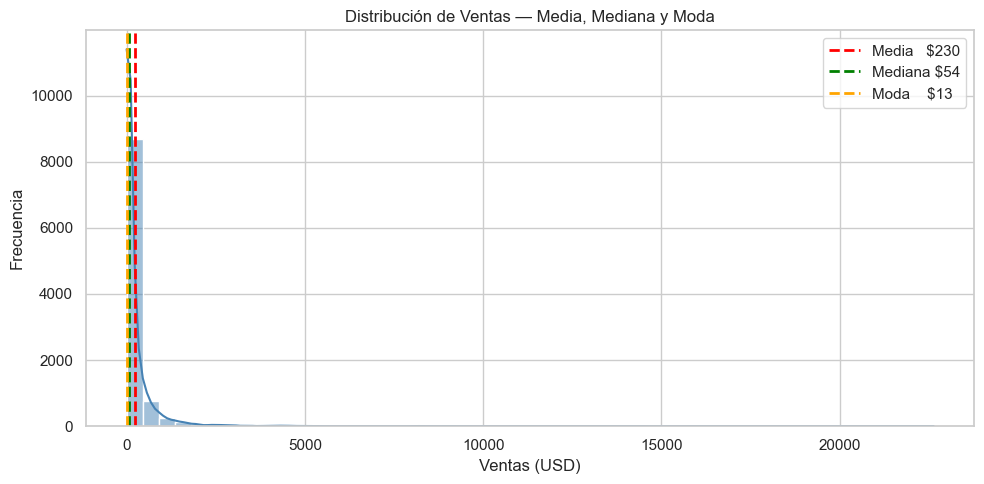

In [299]:
plt.figure(figsize=(10, 5))
sns.histplot(ventas, bins=50, kde=True, color='steelblue')
plt.axvline(media,   color='red',    linestyle='--', linewidth=2, label=f'Media   ${media:,.0f}')
plt.axvline(mediana, color='green',  linestyle='--', linewidth=2, label=f'Mediana ${mediana:,.0f}')
plt.axvline(moda,    color='orange', linestyle='--', linewidth=2, label=f'Moda    ${moda:,.0f}')
plt.title('Distribución de Ventas — Media, Mediana y Moda')
plt.xlabel('Ventas (USD)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

La media ($230) es 4× la mediana ($54) — hay **órdenes muy grandes que distorsionan el promedio**.

Si le reportás al equipo que el ticket promedio es $230, les das una imagen distorsionada. La mediana ($54) es más honesta: la mitad de las órdenes son menores a ese valor.

> **Para el TP:** cuando reportes un promedio, verificá si la distribución es sesgada. Si la media >> mediana, la mediana comunica mejor el caso típico.

### Insight 1 — ¿Qué categoría genera más ventas y más profit?

Respondemos la pregunta central: agrupamos por categoría y calculamos totales.

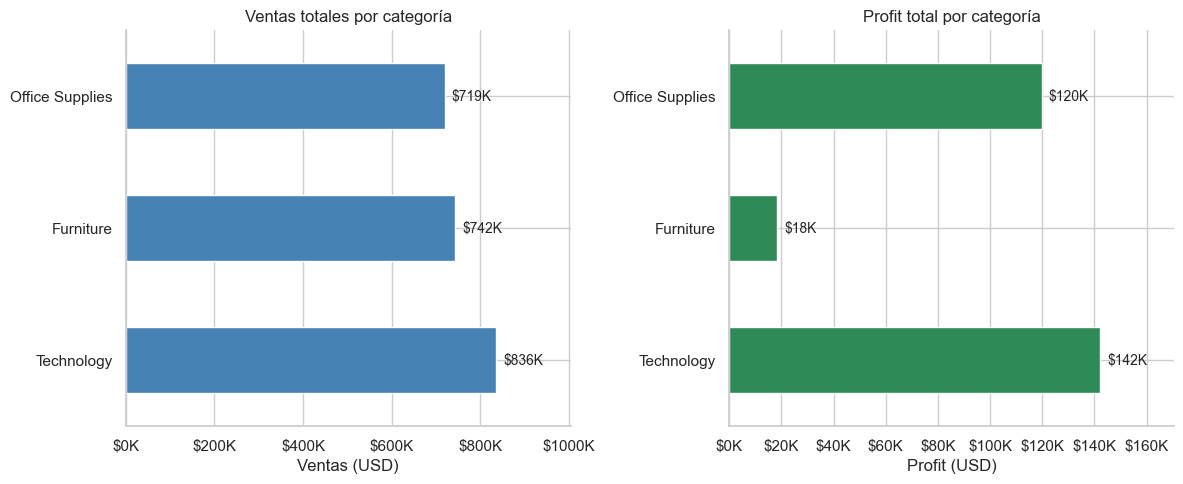

In [300]:
resumen_cat = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

resumen_cat['Sales'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Ventas totales por categoría')
axes[0].set_xlabel('Ventas (USD)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

resumen_cat['Profit'].plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Profit total por categoría')
axes[1].set_xlabel('Profit (USD)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Etiquetas de valor al final de cada barra
for ax, col in zip(axes, ['Sales', 'Profit']):
    max_val = resumen_cat[col].max()
    ax.set_xlim(0, max_val * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, v in enumerate(resumen_cat[col]):
        ax.text(v + max_val * 0.02, i, f'${v/1e3:.0f}K', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

**Technology** lidera en ventas y en profit — es la categoría estrella.
**Furniture** vende casi igual que Office Supplies pero con margen mucho más bajo.

Este patrón **no se veía en el `describe()`** — la agrupación reveló el insight.

> **Para el TP:** `groupby` es tu herramienta principal para encontrar insights. "¿Qué barrio tiene más X?", "¿Qué año tuvo más Y?" → todas se responden con groupby.

### Insight 2 — ¿Los descuentos altos destruyen el margen?

Si Furniture tiene mal margen, ¿puede ser porque ofrece más descuentos? Exploramos la relación entre descuento y profit.

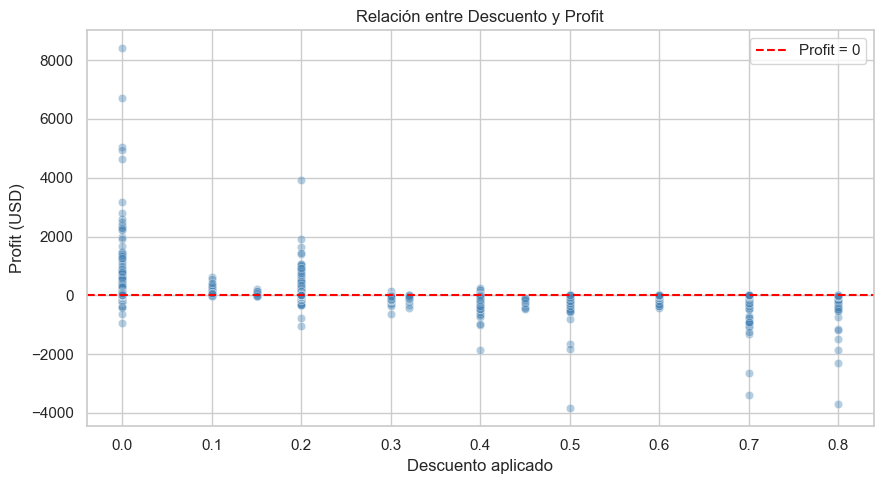

In [301]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Profit = 0')
plt.title('Relación entre Descuento y Profit')
plt.xlabel('Descuento aplicado')
plt.ylabel('Profit (USD)')
plt.legend()
plt.tight_layout()
plt.show()


A medida que el descuento sube, el profit **cae consistentemente y se vuelve negativo**. Las órdenes con descuentos mayores al 40-50% casi siempre pierden plata.

Esta es una decisión de negocio crítica: los descuentos altos están **subsidiando ventas a pérdida**.

> **Para el TP:** buscá relaciones entre dos variables numéricas con un scatter. Un patrón claro (como este) es exactamente el tipo de insight que vale contar en el video.

---
## Paso 4 — Visualizá bien lo que encontraste

### ¿Por qué visualizar?

Un número no comunica solo. Una visualización bien hecha:

- Hace **visibles patrones** que no se detectan con números (tendencias, outliers, relaciones)
- **Reduce el esfuerzo cognitivo** de quien te escucha — entienden en segundos lo que tardaste horas en encontrar
- **Mejora la toma de decisiones** — comunica información clave de forma directa
- **Evita interpretaciones erróneas** si está bien diseñada (sin distorsiones ni ruido visual)
- Permite **contar una historia** con datos — el mensaje queda y convence

> Para el TP: no alcanza con encontrar el insight — tenés que mostrarlo de forma que alguien que no vio el dataset lo entienda en 5 segundos.

---


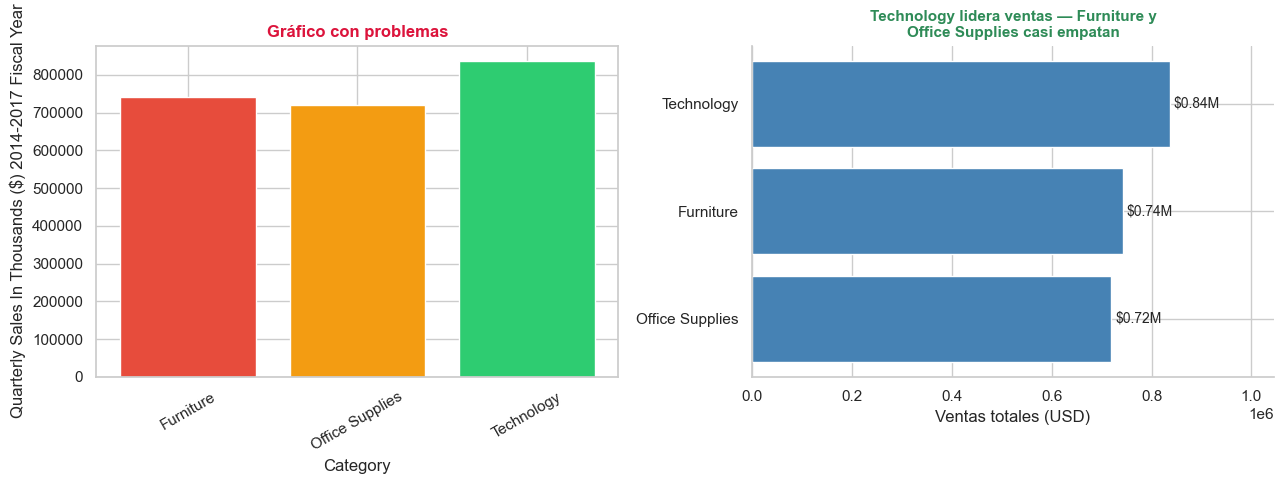

In [302]:
# El mismo dato — dos formas de mostrarlo
cat_sales = df.groupby('Category')['Sales'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── GRAFICO MAL ──────────────────────────────────────────────────────────
axes[0].bar(cat_sales.index, cat_sales.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'])  # colores distintos sin sentido
axes[0].set_title('Sales', fontsize=12)               # título vacío
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Quarterly Sales In Thousands ($) 2014-2017 Fiscal Year')  # eje enorme
axes[0].tick_params(axis='x', rotation=30)

# ── GRAFICO BIEN ─────────────────────────────────────────────────────────
cat_sorted = cat_sales.sort_values(ascending=True)   # ordenado, horizontal
bars = axes[1].barh(cat_sorted.index, cat_sorted.values, color='steelblue')
for bar, val in zip(bars, cat_sorted.values):
    axes[1].text(bar.get_width() + 8000, bar.get_y() + bar.get_height() / 2,
                 f'${val/1e6:.2f}M', va='center', fontsize=10)
axes[1].set_xlabel('Ventas totales (USD)')
axes[1].set_xlim(0, cat_sorted.max() * 1.25)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Títulos que comunican el juicio editorial
axes[0].set_title('Gráfico con problemas', fontsize=12, color='crimson', fontweight='bold')
axes[1].set_title('Technology lidera ventas — Furniture y\nOffice Supplies casi empatan',
                  fontsize=11, color='seagreen', fontweight='bold')

plt.tight_layout()
plt.show()


### Los 5 errores más comunes — reconocelos en tu propio TP

Las slides de clase muestran estos 5 fallos, que aparecen seguido en trabajos reales:

| Error | Descripción | Ejemplo |
|---|---|---|
| **Elegir el gráfico equivocado** | Tipo de gráfico que no sirve para los datos | 9 líneas en un mismo gráfico — no se puede leer nada |
| **Complejizar sin sentido** | Agregar dimensiones o efectos que no agregan información | Barras 3D con profundidad — las proporciones se distorsionan |
| **No decir nada** | Gráfico sin título, sin eje, sin conclusión visible | Treemap donde todos los valores son iguales — ¿qué se supone que hay que ver? |
| **Mal uso del color** | Un color diferente por barra sin que signifique nada | Rainbow bar chart — el ojo no sabe adónde ir |
| **Usar 3D sin razón** | 3D en tortas o barras — distorsiona tamaños y ángulos | 3D pie chart donde los segmentos de adelante parecen más grandes |

###
> El gráfico de la izquierda tiene 3 de estos 5 errores — ¿cuáles encontrás?

Los dos gráficos muestran **exactamente los mismos datos**.

- **Izquierda:** 3 colores sin sentido, eje Y con 60 caracteres, datos sin ordenar, título que no dice nada
- **Derecha:** un color, ordenado, valores anotados, título con el insight, sin ruido visual

> **Antes de incluir un gráfico en el video:** ¿alguien que no vio el dataset puede leer este gráfico en 5 segundos y entender el insight? Si no, simplificá.

---
## Paso 5 — Contá tu historia: el video de 3-5 minutos
### Ejemplo completo con Superstore — lo que dirías en el video

**Pregunta:** ¿Qué categoría de producto genera más valor para el negocio?

**El dataset:** 9.994 órdenes de una empresa retail de EEUU entre 2014 y 2017. 21 variables: fechas, geografía, cliente, producto y transacciones. 799 filas con datos faltantes en Discount y Profit — MCAR, imputamos con 0 y mediana.

**Exploración:** Las ventas son muy asimétricas — la venta mediana es $54 pero hay órdenes de hasta $22.000. Hay 3 categorías: Technology, Furniture y Office Supplies.

**Insight:** Technology lidera ventas ($836K) y tiene el mejor margen. Furniture vende similar a Office Supplies pero con margen mucho más bajo. Los descuentos superiores al 40% destruyen sistemáticamente el profit.

**Conclusión:** Para mejorar rentabilidad sin perder volumen, el negocio debería invertir en Technology y revisar la política de descuentos en Furniture — una categoría que vende mucho pero gana poco.

> Este nivel de análisis es exactamente lo que se espera. No necesitan 10 gráficos — necesitan **una historia convincente con 2-3 visualizaciones bien hechas**.

---

## Ayuda Extra — para explorar en casa

- **Extra 1 — Dispersión en profundidad:** varianza, desviación estándar, IQR, boxplots y detección formal de outliers — los conceptos del teórico aplicados al código
- **Extra 2 — Más preguntas de negocio:** dos análisis adicionales (región y segmento de cliente) para practicar el flujo completo del Paso 3 con distintos tipos de preguntas

---
## Extra 1 — Dispersión en profundidad

### ¿Por qué la media sola no alcanza?

Ya vimos que la distribución de ventas es muy sesgada. Ahora medimos ese sesgo formalmente.

- **Desviación estándar (std):** cuánto se alejan los valores de la media en promedio — en las mismas unidades que la variable
- **IQR (rango intercuartil):** diferencia entre Q3 y Q1 — el 50% central de los datos. Más robusto que std porque ignora los extremos

El boxplot combina todo esto de un vistazo: mediana, IQR, bigotes y outliers.

In [303]:
# Varianza y desviación estándar — ¿qué tan dispersos están los datos?
varianza = ventas.var()   # promedio de desviaciones al cuadrado
std      = ventas.std()   # raíz cuadrada de la varianza (mismas unidades que Sales)

print(f'Varianza:            {varianza:>12,.0f}  (difícil de interpretar — unidades al cuadrado)')
print(f'Desviación estándar: ${std:>11,.2f}  (en USD, comparables con Sales)')
print(f'Media:               ${media:>11,.2f}')
print()
print(f'La std (${std:,.0f}) es {std/media:.1f}x la media → distribución muy dispersa.')
print('Cuando std >> media, la media sola es un mal descriptor del dato típico.')


Varianza:                 388,434  (difícil de interpretar — unidades al cuadrado)
Desviación estándar: $     623.25  (en USD, comparables con Sales)
Media:               $     229.86

La std ($623) es 2.7x la media → distribución muy dispersa.
Cuando std >> media, la media sola es un mal descriptor del dato típico.


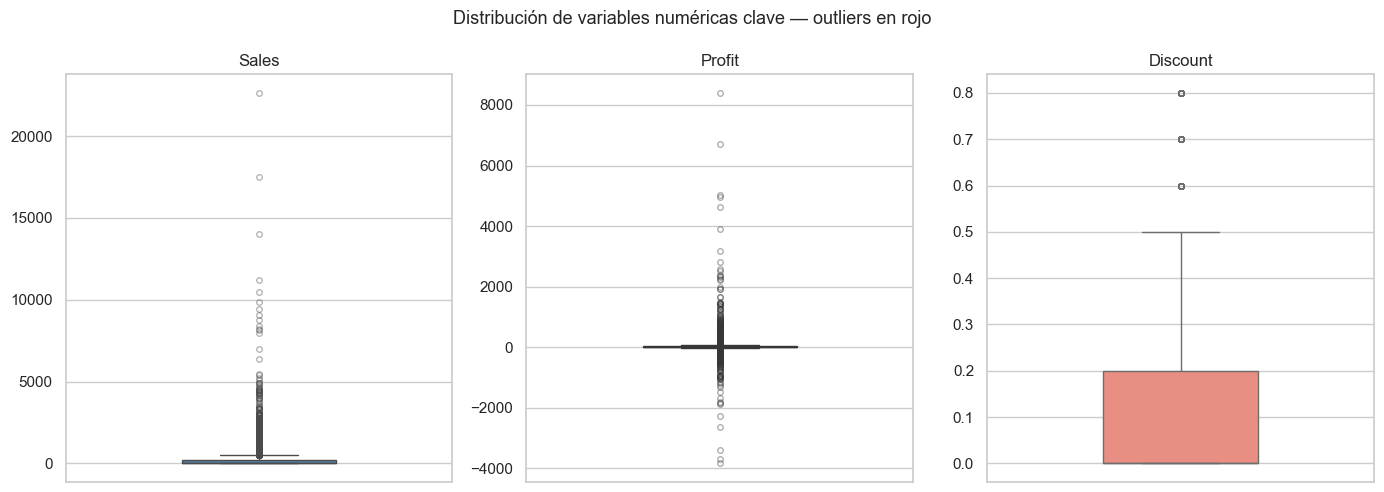

In [304]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, color in zip(axes, ['Sales', 'Profit', 'Discount'], ['steelblue', 'seagreen', 'salmon']):
    data = df[col].dropna()
    sns.boxplot(y=data, ax=ax, color=color, width=0.4,
                flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
    ax.set_title(col)
    ax.set_ylabel('')

plt.suptitle('Distribución de variables numéricas clave — outliers en rojo', fontsize=13)
plt.tight_layout()
plt.show()


### Conclusión

- **Sales:** hay órdenes enormes que son outliers — probablemente clientes corporativos o compras al por mayor
- **Profit:** hay valores **negativos** — órdenes que generan pérdidas. Probablemente por descuentos muy altos
- **Discount:** la mayoría de las órdenes tienen descuentos bajos o nulos, pero hay casos extremos

> Los outliers no siempre son errores — a veces son los datos más interesantes. La clave es entender **por qué existen**.

### Detección formal de outliers con la regla del IQR

In [305]:
def resumen_outliers(serie, nombre):
    s = serie.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    outliers = s[(s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)]
    print(f'{nombre}: {len(outliers)} outliers ({100*len(outliers)/len(s):.1f}%) '
          f'| Límites: [{Q1 - 1.5*IQR:.2f}, {Q3 + 1.5*IQR:.2f}]')

resumen_outliers(df['Sales'],    'Sales   ')
resumen_outliers(df['Profit'],   'Profit  ')
resumen_outliers(df['Discount'], 'Discount')


Sales   : 1167 outliers (11.7%) | Límites: [-271.71, 498.93]
Profit  : 1943 outliers (19.4%) | Límites: [-32.93, 61.02]
Discount: 769 outliers (7.7%) | Límites: [-0.30, 0.50]


---
## Extra 2 — Más preguntas de negocio

Dos análisis adicionales para practicar el flujo completo: pregunta → `groupby` → visualización → insight.

Usá estos como modelo para formular las preguntas de tu TP y reemplazá `'Region'` o `'Segment'` por las columnas de tu dataset de GCBA.

### ¿Qué región performa mejor? — ventas vs margen

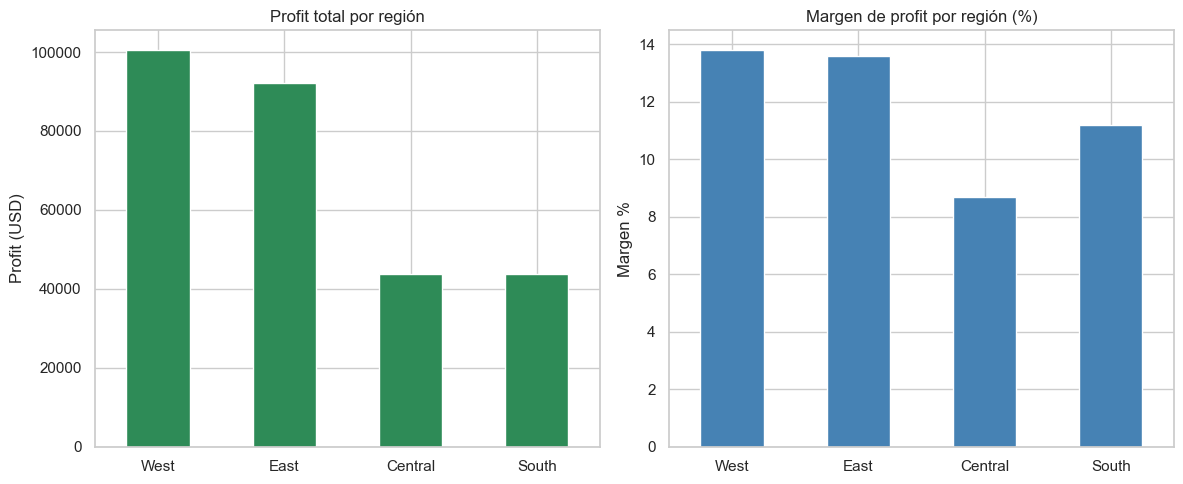

            Sales    Profit  Profit Margin %
Region                                      
West    725457.82 100451.55            13.80
East    678781.24  92234.57            13.60
Central 501239.89  43857.13             8.70
South   391721.91  43703.10            11.20


In [306]:
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum()
region_perf['Profit Margin %'] = (region_perf['Profit'] / region_perf['Sales'] * 100).round(1)
region_perf = region_perf.sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['seagreen' if x > 0 else 'salmon' for x in region_perf['Profit']]
region_perf['Profit'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Profit total por región')
axes[0].set_ylabel('Profit (USD)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

region_perf['Profit Margin %'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Margen de profit por región (%)')
axes[1].set_ylabel('Margen %')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(region_perf)


**West** lidera tanto en profit absoluto como en margen.
**Central** tiene ventas considerables pero el margen más bajo — algo está fallando ahí.

> Dos preguntas naturales para profundizar: ¿qué categorías se venden más en Central? ¿Los descuentos en Central son más altos que en el resto?

### ¿Qué segmento de cliente es más valioso?

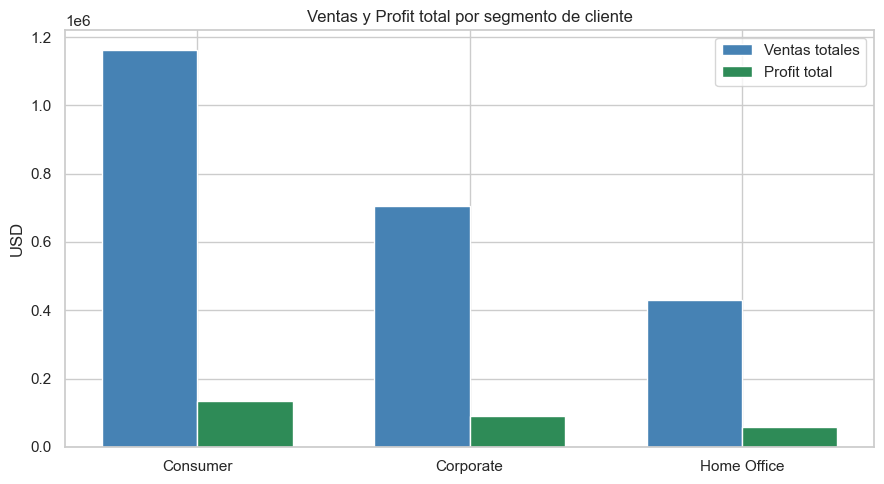

             Ventas totales  Venta promedio  Profit total  Profit promedio
Segment                                                                   
Consumer         1161401.34          223.73     133279.91            25.68
Corporate         706146.37          233.82      90413.76            29.94
Home Office       429653.15          240.97      56552.68            31.72


In [307]:
seg = df.groupby('Segment')[['Sales', 'Profit']].agg(['sum', 'mean']).round(2)
seg.columns = ['Ventas totales', 'Venta promedio', 'Profit total', 'Profit promedio']
seg = seg.sort_values('Profit total', ascending=False)

plt.figure(figsize=(9, 5))
x = range(len(seg))
width = 0.35
plt.bar([i - width/2 for i in x], seg['Ventas totales'], width, label='Ventas totales', color='steelblue')
plt.bar([i + width/2 for i in x], seg['Profit total'],  width, label='Profit total',  color='seagreen')
plt.xticks(x, seg.index)
plt.title('Ventas y Profit total por segmento de cliente')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

print(seg)


**Consumer** es el segmento más grande en ventas y profit total, pero es el que tiene más clientes.
**Home Office**, siendo el más chico, tiene un **profit promedio por orden similar al Corporate**.

> El segmento más grande no siempre es el más rentable por cliente. Para una estrategia de crecimiento, puede ser más eficiente enfocarse en los segmentos más eficientes.

---
## Extra 3 — ¿Qué gráfico usar para qué pregunta?

Elegir el tipo de gráfico equivocado es el error más frecuente (y más visible). Esta guía te ayuda a decidir antes de escribir código.

### Regla general: el tipo de dato determina el gráfico

| Pregunta que querés responder | Tipo de gráfico | Cuándo evitarlo |
|---|---|---|
| ¿Cómo se distribuye una variable numérica? | **Histograma** | No uses barras — las barras son para categorías |
| ¿Cómo se comparan categorías? | **Barras horizontales** (ordenadas) | Evitá pie chart si tenés más de 3-4 categorías |
| ¿Cómo evoluciona algo en el tiempo? | **Línea** | No uses barras para series temporales largas |
| ¿Existe relación entre dos variables numéricas? | **Scatter plot** | No uses línea si los puntos no tienen orden natural |
| ¿Qué proporción ocupa cada parte del todo? | **Torta / donut** solo si hay max 3-4 segmentos con dominancia clara | Con 7 segmentos iguales no se lee nada |
| ¿Cómo se comparan sub-categorías dentro de categorías? | **Barras apiladas** (%) o **barras agrupadas** (valores absolutos) | Apiladas en % cuando importa la composición; absolutas cuando importa el volumen |
| ¿Dónde están los outliers y cómo se dispersan los datos? | **Boxplot** | No uses promedio solo — perdés la info de dispersión |

---

### Barras apiladas: ¿absolutas o en porcentaje?

Depende de **qué querés comparar**:

- **Absolutas:** querés mostrar que una categoría tiene más volumen total que otra
- **Porcentaje (100%):** querés mostrar que la composición interna es diferente entre categorías — aunque los totales sean distintos



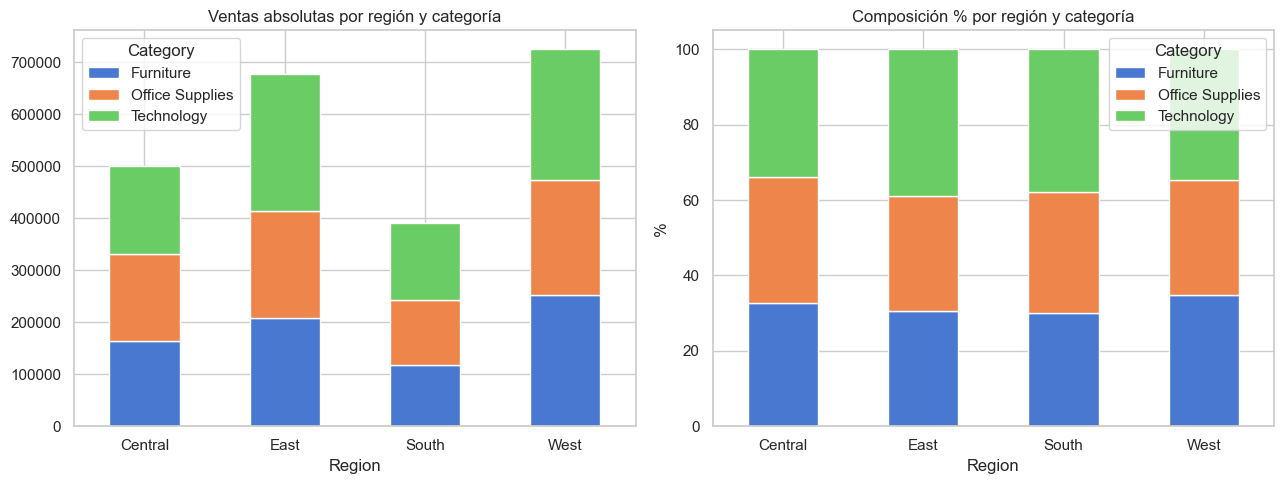

In [308]:
# Ejemplo: ventas por región y categoría — dos formas
pivot = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolutas — importa el volumen
pivot.plot(kind='bar', ax=axes[0], stacked=True)
axes[0].set_title('Ventas absolutas por región y categoría')
axes[0].tick_params(axis='x', rotation=0)

# Porcentaje — importa la composición
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Composición % por región y categoría')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---

### Gráfico de tortas — cuándo sí y cuándo no

**Funciona** cuando:
- Hay máximo 3-4 segmentos
- Un segmento domina claramente (ej: 60%, 25%, 15%)
- El mensaje es "X representa la mayoría"

**No funciona** cuando:
- Hay 5+ segmentos de tamaños similares — el ojo no distingue ángulos parecidos
- Querés comparar exactitud — las barras son más fáciles de leer con precisión
- Usás 3D — distorsiona los ángulos y hace que los segmentos de adelante parezcan más grandes

> Para el TP: si tu insight es "la categoría X domina con el 60%", una torta puede funcionar. Si tu insight es "estas 5 categorías son similares", usá barras ordenadas.